In [322]:
from datetime import datetime
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split as tts
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [323]:

data = pd.read_csv('/content/Loan payments data.csv')
data.head()

,Loan_ID,loan_status,Principal,terms,effective_date,due_date,paid_off_time,past_due_days,age,education,Gender
0,xqd20166231,PAIDOFF,1000,30,9/8/2016,10/7/2016,9/14/2016 19:31,NaN,45,High School or Below,male
1,xqd20168902,PAIDOFF,1000,30,9/8/2016,10/7/2016,10/7/2016 9:00,NaN,50,Bechalor,female
2,xqd20160003,PAIDOFF,1000,30,9/8/2016,10/7/2016,9/25/2016 16:58,NaN,33,Bechalor,female
3,xqd20160004,PAIDOFF,1000,15,9/8/2016,9/22/2016,9/22/2016 20:00,NaN,27,college,male
4,xqd20160005,PAIDOFF,1000,30,9/9/2016,10/8/2016,9/23/2016 21:36,NaN,28,college,female


In [324]:
data.shape

(500, 11)

In [325]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Loan_ID         500 non-null    object 
 1   loan_status     500 non-null    object 
 2   Principal       500 non-null    int64  
 3   terms           500 non-null    int64  
 4   effective_date  500 non-null    object 
 5   due_date        500 non-null    object 
 6   paid_off_time   400 non-null    object 
 7   past_due_days   200 non-null    float64
 8   age             500 non-null    int64  
 9   education       500 non-null    object 
 10  Gender          500 non-null    object 
dtypes: float64(1), int64(3), object(7)
memory usage: 43.1+ KB


In [326]:
data.describe()

,Principal,terms,past_due_days,age
count,500.000000,500.000000,200.00000,500.000000
mean,943.200000,22.824000,36.01000,31.116000
std,115.240274,8.000064,29.38088,6.084784
min,300.000000,7.000000,1.00000,18.000000
25%,1000.000000,15.000000,3.00000,27.000000
50%,1000.000000,30.000000,37.00000,30.000000
75%,1000.000000,30.000000,60.00000,35.000000
max,1000.000000,30.000000,76.00000,51.000000


In [327]:
data.isna().sum()

,0
Loan_ID,0
loan_status,0
Principal,0
terms,0
effective_date,0
due_date,0
paid_off_time,100
past_due_days,300
age,0
education,0


In [328]:
#converting the String into to int value using the datetime
data['effective_date'] = pd.to_datetime(data['effective_date'])
data['paid_off_time']=pd.to_datetime(data['paid_off_time'])
data['due_date']=pd.to_datetime(data['due_date'])

In [329]:
median= data['paid_off_time'].median()
data['paid_off_time'].fillna(median,inplace=True)

/tmp/ipykernel_875/4107628813.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['paid_off_time'].fillna(median,inplace=True)


In [330]:
# 3. Feature Engineering: Calculating the "Loan Duration"
# Real-world tip: Models love durations (days) more than specific dates
data['day_of_week'] = data['effective_date'].dt.dayofweek
data['deadline_days'] = (data['due_date'] - data['effective_date']).dt.days

In [331]:
#filling the pas due days with zeros as many of people may have been completer
data['past_due_days']=data['past_due_days'].fillna(0)

In [332]:
data.head()

,Loan_ID,loan_status,Principal,terms,effective_date,due_date,paid_off_time,past_due_days,age,education,Gender,day_of_week,deadline_days
0,xqd20166231,PAIDOFF,1000,30,2016-09-08,2016-10-07,2016-09-14 19:31:00,0.0,45,High School or Below,male,3,29
1,xqd20168902,PAIDOFF,1000,30,2016-09-08,2016-10-07,2016-10-07 09:00:00,0.0,50,Bechalor,female,3,29
2,xqd20160003,PAIDOFF,1000,30,2016-09-08,2016-10-07,2016-09-25 16:58:00,0.0,33,Bechalor,female,3,29
3,xqd20160004,PAIDOFF,1000,15,2016-09-08,2016-09-22,2016-09-22 20:00:00,0.0,27,college,male,3,14
4,xqd20160005,PAIDOFF,1000,30,2016-09-09,2016-10-08,2016-09-23 21:36:00,0.0,28,college,female,4,29


/tmp/ipykernel_875/2981974078.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='loan_status', data=data, palette='viridis', ax=axes[0, 0])
/tmp/ipykernel_875/2981974078.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='loan_status', y='age', data=data, palette='magma', ax=axes[0, 1])


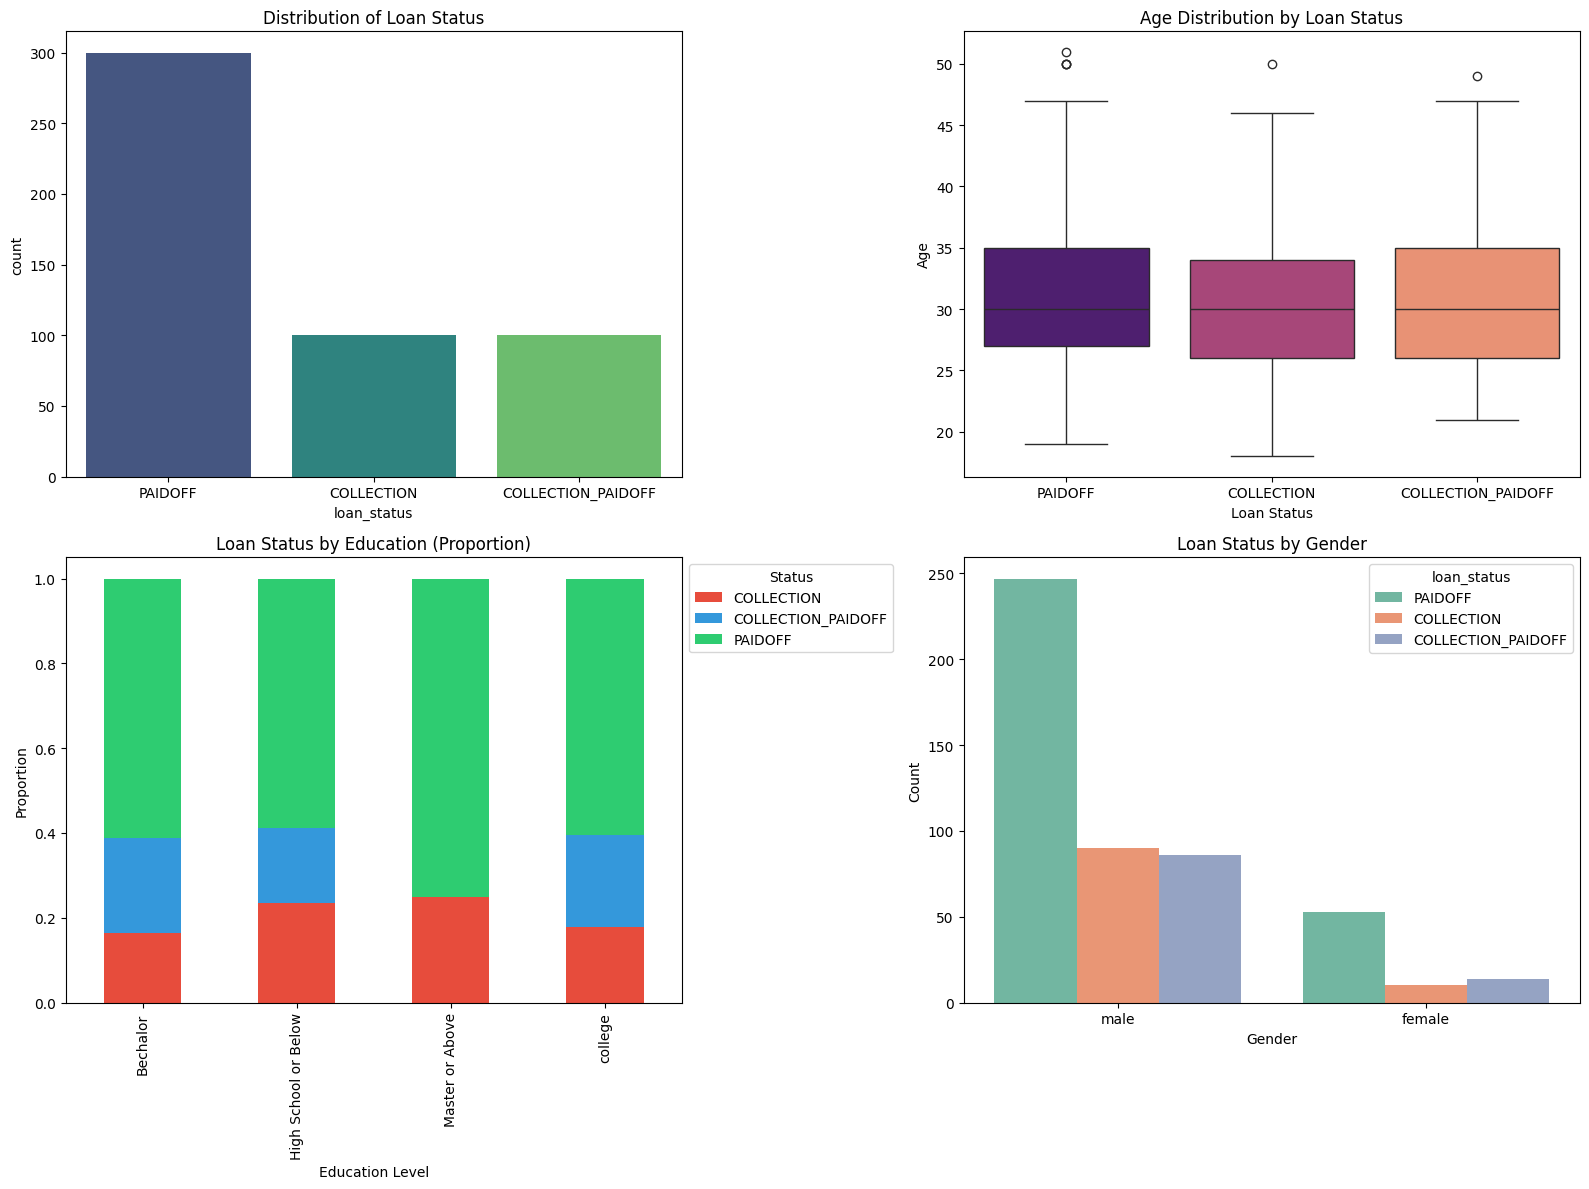

In [333]:
from pandas.core.arrays.datetimes import DatetimeArray
# Setup the figure
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Visualization 1: Loan Status Distribution
sns.countplot(x='loan_status', data=data, palette='viridis', ax=axes[0, 0])
axes[0, 0].set_title('Distribution of Loan Status')

# Visualization 2: Age vs Loan Status
sns.boxplot(x='loan_status', y='age', data=data, palette='magma', ax=axes[0, 1])
axes[0, 1].set_title('Age Distribution by Loan Status')
axes[0, 1].set_xlabel('Loan Status')
axes[0, 1].set_ylabel('Age')

# Visualization 3: Education vs Loan Status
# Creating a cross-tabulation for better visualization of proportions
edu_loan = pd.crosstab(data['education'], data['loan_status'], normalize='index')
edu_loan.plot(kind='bar', stacked=True, ax=axes[1, 0], color=['#e74c3c', '#3498db', '#2ecc71'])
axes[1, 0].set_title('Loan Status by Education (Proportion)')
axes[1, 0].set_xlabel('Education Level')
axes[1, 0].set_ylabel('Proportion')
axes[1, 0].legend(title='Status', bbox_to_anchor=(1, 1))

# Visualization 4: Gender vs Loan Status
sns.countplot(x='Gender', hue='loan_status', data=data, palette='Set2', ax=axes[1, 1])
axes[1, 1].set_title('Loan Status by Gender')
axes[1, 1].set_xlabel('Gender')
axes[1, 1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('eda_visualizations.png')

1. Distribution of Loan Status: This tells us if our data is "imbalanced." If we have 400 "Paid" but only 50 "Default," the model will struggle to learn what a "Default" looks like. In your data, we see a decent split, but we still need to be careful.

2. Age vs. Loan Status: The boxplot shows the "median age" for each group. If the "Collection" (Default) box is much lower than the "Paid" box, it tells the model that younger people might be a higher risk.

3. Education vs. Repayment: This is a Stacked Bar Chart. It shows the percentage of people in each education level who paid back. This is very powerful for a bank because it clearly shows if, for example, "Bachelor" holders are safer to lend to than "High School" graduates.

4. Principal vs. Loan Status: The violin plot shows where the "money" is. Most loans are for $800 or $1000. It helps us see if people taking larger loans ($1000) are defaulting more often than those taking smaller ones ($800).

In [334]:
# 4. Handling the Target Variable (loan_status)
# We convert 'PAIDOFF' to 1 (Good) and 'COLLECTION'/'COLLECTION_PAIDOFF' to 0 (Default)
data['loan_status'] = data['loan_status'].apply(lambda x: 1 if x == 'PAIDOFF' else 0)

In [335]:
# Encoding Gender
#instead  of using the lambada we can alo use the map function to convert the categorical value into the numerical
data ['Gender']=data['Gender'].map({'male':0, 'female':1})
data.head()

,Loan_ID,loan_status,Principal,terms,effective_date,due_date,paid_off_time,past_due_days,age,education,Gender,day_of_week,deadline_days
0,xqd20166231,1,1000,30,2016-09-08,2016-10-07,2016-09-14 19:31:00,0.0,45,High School or Below,0,3,29
1,xqd20168902,1,1000,30,2016-09-08,2016-10-07,2016-10-07 09:00:00,0.0,50,Bechalor,1,3,29
2,xqd20160003,1,1000,30,2016-09-08,2016-10-07,2016-09-25 16:58:00,0.0,33,Bechalor,1,3,29
3,xqd20160004,1,1000,15,2016-09-08,2016-09-22,2016-09-22 20:00:00,0.0,27,college,0,3,14
4,xqd20160005,1,1000,30,2016-09-09,2016-10-08,2016-09-23 21:36:00,0.0,28,college,1,4,29


In [336]:
#one hot encoding for eduction
eduction_dummies =  pd.get_dummies(data['education'],drop_first=True)
# Concatinating the eduction column into the main data set.
data = pd.concat([data,eduction_dummies],axis=1)
data.drop('education',axis=1,inplace=True)

In [337]:
# 4. Feature Selection
# In production, we drop columns that are "Leakage" (info the model wouldn't have at the time of application)
# or redundant (like Loan_ID)
features = ['Principal', 'terms', 'age', 'Gender', 'deadline_days', 'day_of_week',
            'High School or Below', 'Master or Above', 'college']

x = data[features]
y = data['loan_status']

In [338]:
#Splint the data into the train test
x_train,x_test,y_train,y_test = tts(x,y,test_size=0.2,random_state=42)

#Initializing the Standarscaler
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.fit_transform(x_test)
x.head()

,Principal,terms,age,Gender,deadline_days,day_of_week,High School or Below,Master or Above,college
0,1000,30,45,0,29,3,True,False,False
1,1000,30,50,1,29,3,False,False,False
2,1000,30,33,1,29,3,False,False,False
3,1000,15,27,0,14,3,False,False,True
4,1000,30,28,1,29,4,False,False,True


In [339]:
# "Liblineat" is model a machine learning library specifically designed for large-scale linear classification and regression problems
model = LogisticRegression(solver='liblinear')

# Training (The 'Learning' phase)
# The model calculates weights for Age, Gender, Education, etc.
model.fit(x_train,y_train)

#lets perform the prediction our test data set
y_pred = model.predict(x_test)
y_pred

array([1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1,
       1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1,
       0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0,
       1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1,
       0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1])

In a bank, Recall is more important than Accuracy. If we have 90% accuracy but our Recall for "Default" is 0%, we are a bad bank because we didn't catch a single person who would steal the money! This report tells us if we are actually catching the "bad" loans.

In [340]:
print("\n--- Detailed Performance Report ---")
# Precision tells us: 'Of all people we predicted would default, how many actually did?'
# Recall tells us: 'Of all people who actually defaulted, how many did we catch?'
print(classification_report(y_test, y_pred))

#0 means Default and 1 means Paid Off.


--- Detailed Performance Report ---
              precision    recall  f1-score   support

           0       0.57      0.33      0.42        48
           1       0.56      0.77      0.65        52

    accuracy                           0.56       100
   macro avg       0.56      0.55      0.53       100
weighted avg       0.56      0.56      0.54       100



1. Precision (0.57): When the model says "This person will default," it is right 57% of the time.  often—rejecting good people by mistake.
2. Recall (0.77): The model is much better at identifying people who will pay. It caught 77% of the successful loans.
3. supprt :- 48 people who defaulted and 52 who paid. This is a very "balanced" test set, which is good for testing.

In [341]:
print("--- Model Accuracy ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred)} ")

--- Model Accuracy ---
Accuracy: 0.56 


In [342]:
import joblib

# 1. Save the trained model to a file
joblib.dump(model, 'loan_model.pkl')

# 2. Save the scaler (Crucial! New data must be scaled exactly like training data)
joblib.dump(scaler, 'scaler.pkl')

print("--- Model & Scaler Saved Successfully! ---")

--- Model & Scaler Saved Successfully! ---
